Importons toutes les bibliotheques necessaires

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

**Partie 1 — Exploration et Analyse des Données (EDA)**



importer la base de données et l'afficher

In [ ]:
URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(URL)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Nombre de colonnes et de lignes

In [ ]:
df.shape

(891, 12)

l'entete de la base

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


voyons toutes les informations de la base

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


voyons le resumé statistique de la bas e

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


les valeurs manquantes par colonne

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Q1. Taux de survie global

In [31]:
taux = df['Survived'].value_counts(normalize=True)
print('Taux de survie global :')
print(f"  Décédés  (0) : {taux[0]:.1%}")
print(f"  Survivants (1) : {taux[1]:.1%}")

Taux de survie global :
  Décédés  (0) : 61.6%
  Survivants (1) : 38.4%


Q2. Survie par sexe

Taux de survie par sexe :
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


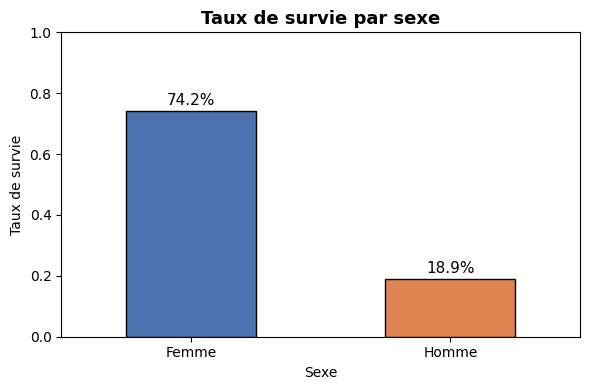

In [32]:
survie_sexe = df.groupby('Sex')['Survived'].mean()
print('Taux de survie par sexe :')
print(survie_sexe)

fig, ax = plt.subplots(figsize=(6, 4))
survie_sexe.plot(kind='bar', color=['#4C72B0', '#DD8452'], ax=ax, edgecolor='black')
ax.set_title('Taux de survie par sexe', fontsize=13, fontweight='bold')
ax.set_xlabel('Sexe')
ax.set_ylabel('Taux de survie')
ax.set_ylim(0, 1)
ax.set_xticklabels(['Femme', 'Homme'], rotation=0)
for i, v in enumerate(survie_sexe):
    ax.text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

Q3 — Taux de survie par classe

Taux de survie par classe :
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


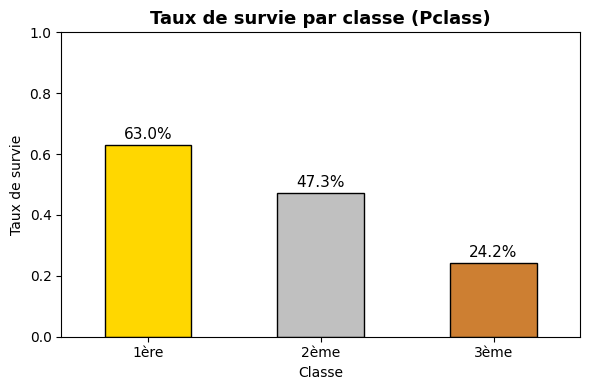

In [33]:
survie_classe = df.groupby('Pclass')['Survived'].mean()
print('Taux de survie par classe :')
print(survie_classe)

fig, ax = plt.subplots(figsize=(6, 4))
survie_classe.plot(kind='bar', color=['gold', 'silver', '#CD7F32'], ax=ax, edgecolor='black')
ax.set_title('Taux de survie par classe (Pclass)', fontsize=13, fontweight='bold')
ax.set_xlabel('Classe')
ax.set_ylabel('Taux de survie')
ax.set_ylim(0, 1)
ax.set_xticklabels(['1ère', '2ème', '3ème'], rotation=0)
for i, v in enumerate(survie_classe):
    ax.text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

Q4 — Distribution de l'âge et valeurs manquantes

Valeurs manquantes dans Age : 177 (19.9%)


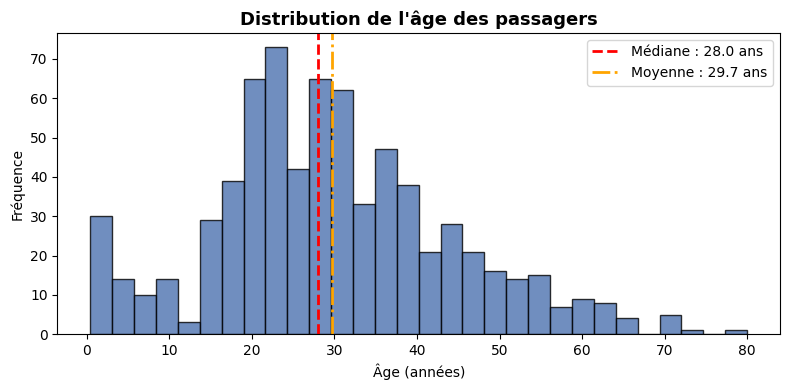

In [34]:
nb_nan_age = df['Age'].isnull().sum()
print(f'Valeurs manquantes dans Age : {nb_nan_age} ({nb_nan_age/len(df):.1%})')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['Age'].dropna(), bins=30, color='#4C72B0', edgecolor='black', alpha=0.8)
ax.axvline(df['Age'].median(), color='red', linestyle='--', linewidth=2,
           label=f"Médiane : {df['Age'].median():.1f} ans")
ax.axvline(df['Age'].mean(), color='orange', linestyle='-.', linewidth=2,
           label=f"Moyenne : {df['Age'].mean():.1f} ans")
ax.set_title('Distribution de l\'âge des passagers', fontsize=13, fontweight='bold')
ax.set_xlabel('Âge (années)')
ax.set_ylabel('Fréquence')
ax.legend()
plt.tight_layout()
plt.show()

Q5 — Matrice de corrélation

Corrélations avec Survived (triées) :
Survived    1.000000
Sex_enc     0.543351
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.077221
Pclass     -0.338481
Name: Survived, dtype: float64


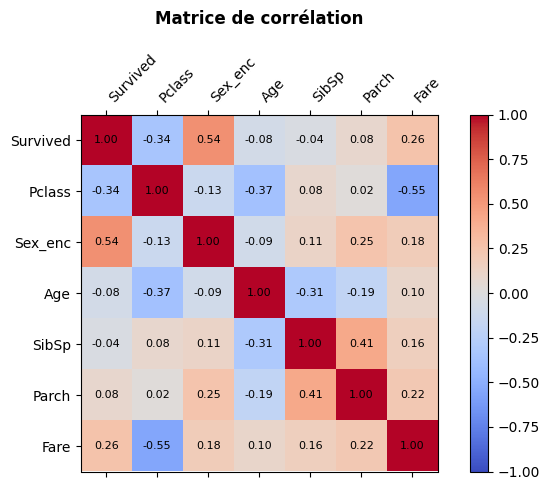

In [35]:
df_corr = df.copy()
df_corr['Sex_enc'] = df_corr['Sex'].map({'male': 0, 'female': 1})

cols_num = ['Survived', 'Pclass', 'Sex_enc', 'Age', 'SibSp', 'Parch', 'Fare']
corr = df_corr[cols_num].corr()

print('Corrélations avec Survived (triées) :')
print(corr['Survived'].sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(7, 5))
cax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(cax)
ax.set_xticks(range(len(cols_num)))
ax.set_yticks(range(len(cols_num)))
ax.set_xticklabels(cols_num, rotation=45, ha='left')
ax.set_yticklabels(cols_num)
for i in range(len(cols_num)):
    for j in range(len(cols_num)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Matrice de corrélation', pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

**Partie 2 — Prétraitement des Données**

Q6 — Sélection des features et de la cible

In [36]:
df_prep = pd.read_csv(URL)

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']

print(f'Dimensions de X (avant preprocessing) : {df_prep[features].shape}')
print(f'Dimensions de y : {df_prep["Survived"].shape}')

Dimensions de X (avant preprocessing) : (891, 6)
Dimensions de y : (891,)


Q7 — Imputation des valeurs manquantes de Age

In [38]:
avant = df_prep['Age'].isnull().sum()
mediane_age = df_prep['Age'].median()

df_prep['Age'] = df_prep['Age'].fillna(mediane_age)

apres = df_prep['Age'].isnull().sum()
print(f'NaN Age avant : {avant} → après : {apres}')
print(f'Médiane utilisée : {mediane_age} ans')

df_prep['Fare'] = df_prep['Fare'].fillna(df_prep['Fare'].median())

NaN Age avant : 0 → après : 0
Médiane utilisée : 28.0 ans


Q8 — Encodage de Sex et normalisation Min-Max

In [39]:
df_prep['Sex'] = df_prep['Sex'].map({'male': 0, 'female': 1})

X = df_prep[features].values.astype(float)
y = df_prep['Survived'].values.reshape(-1, 1)

X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_norm = (X - X_min) / (X_max - X_min)

print(f'Min global après normalisation : {X_norm.min():.4f}')
print(f'Max global après normalisation : {X_norm.max():.4f}')
print(f'Min par feature : {X_norm.min(axis=0)}')
print(f'Max par feature : {X_norm.max(axis=0)}')

Min global après normalisation : 0.0000
Max global après normalisation : 1.0000
Min par feature : [0. 0. 0. 0. 0. 0.]
Max par feature : [1. 1. 1. 1. 1. 1.]


Q9 — Train/Test split (80/20)

In [40]:
np.random.seed(42)
idx = np.random.permutation(len(X_norm))
split = int(0.8 * len(idx))

X_train = X_norm[idx[:split]]
X_test  = X_norm[idx[split:]]
y_train = y[idx[:split]]
y_test  = y[idx[split:]]

print(f'X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}   |  y_test  : {y_test.shape}')

X_train : (712, 6)  |  y_train : (712, 1)
X_test  : (179, 6)   |  y_test  : (179, 1)


**Partie 3 — Architecture du Réseau et Propagation Avant**

Q10 & Q11 — Classe NeuralNetwork : init et forward

In [42]:
class NeuralNetwork:

    def __init__(self, layer_dims):
        self.L = len(layer_dims) - 1
        self.W = {}
        self.b = {}

        for l in range(1, self.L + 1):
            n_in  = layer_dims[l - 1]
            n_out = layer_dims[l]
            self.W[l] = np.random.randn(n_out, n_in) * np.sqrt(2.0 / (n_in + n_out))
            self.b[l] = np.zeros((n_out, 1))

        print('── Dimensions des matrices de poids ──')
        for l in range(1, self.L + 1):
            print(f'  Couche {l} : W{l} = {self.W[l].shape}  |  b{l} = {self.b[l].shape}')

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def sigmoid_d(self, z):
        s = self.sigmoid(z)
        return s * (1 - s)

    def relu(self, z):
        return np.maximum(0, z)

    def relu_d(self, z):
        return (z > 0).astype(float)

    def forward(self, X):
        self.Z = {}
        self.A = {0: X}

        for l in range(1, self.L + 1):
            self.Z[l] = self.W[l] @ self.A[l - 1] + self.b[l]

            self.A[l] = self.sigmoid(self.Z[l])

        return self.A[self.L]

    def compute_cost(self, y_hat, y):
        m = y.shape[1]
        eps = 1e-8
        cost = -(1 / m) * np.sum(
            y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps)
        )
        return float(cost)

    def backward(self, y):
        m = y.shape[1]
        self.dW = {}
        self.db = {}

        delta = -(y - self.A[self.L])
        self.dW[self.L] = (1 / m) * delta @ self.A[self.L - 1].T
        self.db[self.L] = (1 / m) * np.sum(delta, axis=1, keepdims=True)

        for l in range(self.L - 1, 0, -1):
            delta = (self.W[l + 1].T @ delta) * self.sigmoid_d(self.Z[l])
            self.dW[l] = (1 / m) * delta @ self.A[l - 1].T
            self.db[l] = (1 / m) * np.sum(delta, axis=1, keepdims=True)


    def update_params(self, alpha):
        for l in range(1, self.L + 1):
            self.W[l] -= alpha * self.dW[l]
            self.b[l] -= alpha * self.db[l]


    def train(self, X, y, alpha=0.01, epochs=1000, verbose=True):
        history = []
        for epoch in range(1, epochs + 1):
            y_hat = self.forward(X)
            cost  = self.compute_cost(y_hat, y)
            self.backward(y)
            self.update_params(alpha)

            if epoch % 100 == 0:
                history.append((epoch, cost))
                if verbose:
                    print(f'Epoch {epoch:4d} / {epochs}  →  Cost = {cost:.6f}')
        return history


    def predict(self, X, threshold=0.5):
        y_hat = self.forward(X)
        return (y_hat >= threshold).astype(int)


print('Classe NeuralNetwork définie.')

Classe NeuralNetwork définie.


Instanciation du réseau — Architecture 6→8→8→4→1

In [43]:
nn = NeuralNetwork([6, 8, 8, 4, 1])

── Dimensions des matrices de poids ──
  Couche 1 : W1 = (8, 6)  |  b1 = (8, 1)
  Couche 2 : W2 = (8, 8)  |  b2 = (8, 1)
  Couche 3 : W3 = (4, 8)  |  b3 = (4, 1)
  Couche 4 : W4 = (1, 4)  |  b4 = (1, 1)


Q12 — Test de la propagation avant sur 5 exemples

In [44]:
X_train_T = X_train.T
X_test_T  = X_test.T
y_train_T = y_train.T
y_test_T  = y_test.T

X5 = X_test_T[:, :5]   # (6, 5)
y5 = y_test_T[:, :5]   # (1, 5)

y_hat_5 = nn.forward(X5)
print('Sorties du réseau (avant entraînement, 5 exemples) :')
print(y_hat_5)
print(f'Vraies étiquettes : {y5}')
print(f'Min : {y_hat_5.min():.4f}  |  Max : {y_hat_5.max():.4f}  (doit être dans [0, 1])')

Sorties du réseau (avant entraînement, 5 exemples) :
[[0.47828762 0.47853031 0.47756544 0.47720403 0.47759313]]
Vraies étiquettes : [[0 0 1 1 1]]
Min : 0.4772  |  Max : 0.4785  (doit être dans [0, 1])


Q13 [Bonus] — Variante ReLU dans les couches cachées

In [45]:
print('Q13 [Bonus] : ReLU est disponible dans la classe (méthodes relu et relu_d).')
print('La variante ReLU+Sigmoid sera comparée en Q18.')

Q13 [Bonus] : ReLU est disponible dans la classe (méthodes relu et relu_d).
La variante ReLU+Sigmoid sera comparée en Q18.


**Partie 4 — Fonction de Coût et Rétropropagation**

Q14 — Coût initial (avant entraînement)

In [46]:
nn_fresh = NeuralNetwork([6, 8, 8, 4, 1])
y_hat_init = nn_fresh.forward(X_train_T)
cout_initial = nn_fresh.compute_cost(y_hat_init, y_train_T)
print(f'Coût initial (avant entraînement) : {cout_initial:.4f}')

── Dimensions des matrices de poids ──
  Couche 1 : W1 = (8, 6)  |  b1 = (8, 1)
  Couche 2 : W2 = (8, 8)  |  b2 = (8, 1)
  Couche 3 : W3 = (4, 8)  |  b3 = (4, 1)
  Couche 4 : W4 = (1, 4)  |  b4 = (1, 1)
Coût initial (avant entraînement) : 0.6686


Q17 — Entraînement sur 1000 epochs et courbe de convergence

── Dimensions des matrices de poids ──
  Couche 1 : W1 = (8, 6)  |  b1 = (8, 1)
  Couche 2 : W2 = (8, 8)  |  b2 = (8, 1)
  Couche 3 : W3 = (4, 8)  |  b3 = (4, 1)
  Couche 4 : W4 = (1, 4)  |  b4 = (1, 1)
=== Entraînement : alpha=0.01, 1000 epochs ===
Epoch  100 / 1000  →  Cost = 0.721455
Epoch  200 / 1000  →  Cost = 0.683003
Epoch  300 / 1000  →  Cost = 0.672640
Epoch  400 / 1000  →  Cost = 0.669757
Epoch  500 / 1000  →  Cost = 0.668931
Epoch  600 / 1000  →  Cost = 0.668683
Epoch  700 / 1000  →  Cost = 0.668602
Epoch  800 / 1000  →  Cost = 0.668569
Epoch  900 / 1000  →  Cost = 0.668549
Epoch 1000 / 1000  →  Cost = 0.668533


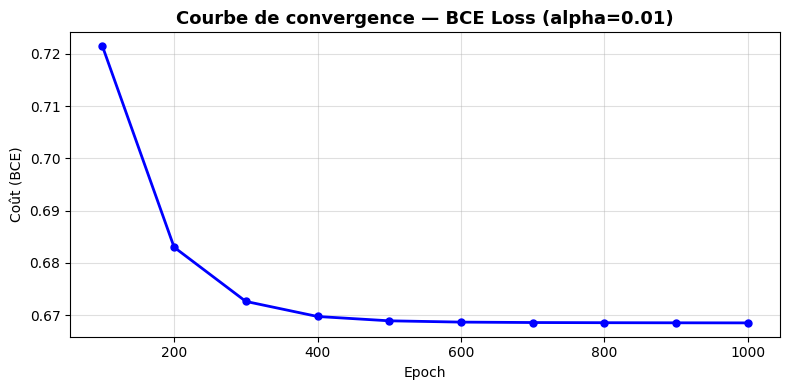

In [47]:
nn_main = NeuralNetwork([6, 8, 8, 4, 1])

print('=== Entraînement : alpha=0.01, 1000 epochs ===')
history = nn_main.train(X_train_T, y_train_T, alpha=0.01, epochs=1000)

epochs_hist = [h[0] for h in history]
costs_hist  = [h[1] for h in history]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_hist, costs_hist, 'b-o', markersize=5, linewidth=2)
ax.set_title('Courbe de convergence — BCE Loss (alpha=0.01)', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Coût (BCE)')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Q18 — Comparaison de différents taux d'apprentissage

── Dimensions des matrices de poids ──
  Couche 1 : W1 = (8, 6)  |  b1 = (8, 1)
  Couche 2 : W2 = (8, 8)  |  b2 = (8, 1)
  Couche 3 : W3 = (4, 8)  |  b3 = (4, 1)
  Couche 4 : W4 = (1, 4)  |  b4 = (1, 1)
── Dimensions des matrices de poids ──
  Couche 1 : W1 = (8, 6)  |  b1 = (8, 1)
  Couche 2 : W2 = (8, 8)  |  b2 = (8, 1)
  Couche 3 : W3 = (4, 8)  |  b3 = (4, 1)
  Couche 4 : W4 = (1, 4)  |  b4 = (1, 1)
── Dimensions des matrices de poids ──
  Couche 1 : W1 = (8, 6)  |  b1 = (8, 1)
  Couche 2 : W2 = (8, 8)  |  b2 = (8, 1)
  Couche 3 : W3 = (4, 8)  |  b3 = (4, 1)
  Couche 4 : W4 = (1, 4)  |  b4 = (1, 1)
── Dimensions des matrices de poids ──
  Couche 1 : W1 = (8, 6)  |  b1 = (8, 1)
  Couche 2 : W2 = (8, 8)  |  b2 = (8, 1)
  Couche 3 : W3 = (4, 8)  |  b3 = (4, 1)
  Couche 4 : W4 = (1, 4)  |  b4 = (1, 1)


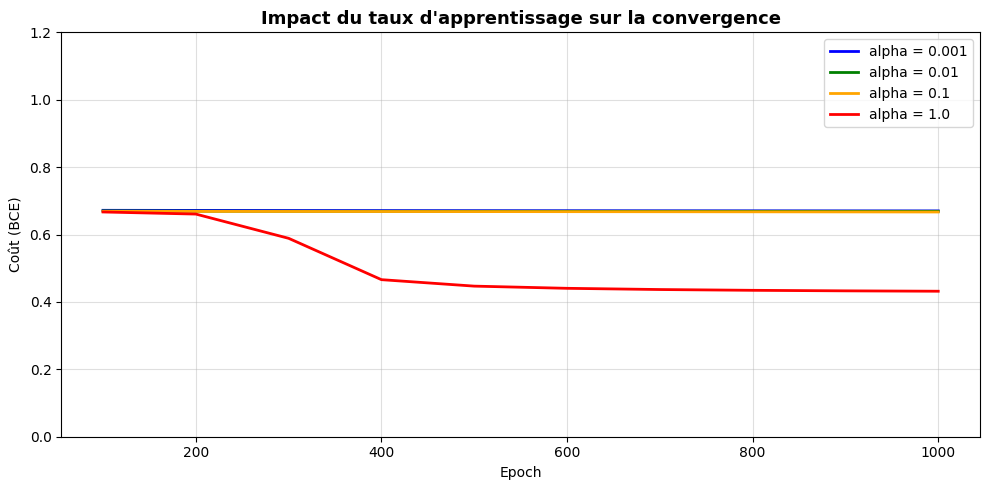

In [48]:
alphas = [0.001, 0.01, 0.1, 1.0]
colors = ['blue', 'green', 'orange', 'red']

fig, ax = plt.subplots(figsize=(10, 5))

for alpha, color in zip(alphas, colors):
    np.random.seed(42)
    nn_temp = NeuralNetwork([6, 8, 8, 4, 1])
    hist = nn_temp.train(X_train_T, y_train_T, alpha=alpha, epochs=1000, verbose=False)
    ep = [h[0] for h in hist]
    co = [h[1] for h in hist]
    ax.plot(ep, co, color=color, linewidth=2, label=f'alpha = {alpha}')

ax.set_title('Impact du taux d\'apprentissage sur la convergence', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Coût (BCE)')
ax.legend()
ax.grid(True, alpha=0.4)
ax.set_ylim(0, 1.2)
plt.tight_layout()
plt.show()


**Partie 5 — Évaluation des Performances**

Q19 — Accuracy sur train et test

In [49]:
y_hat_train = nn_main.forward(X_train_T)
y_hat_test  = nn_main.forward(X_test_T)

y_pred_train = (y_hat_train >= 0.5).astype(int)
y_pred_test  = (y_hat_test  >= 0.5).astype(int)

def accuracy(y_pred, y_true):
    return float(np.mean(y_pred == y_true))

acc_train = accuracy(y_pred_train, y_train_T)
acc_test  = accuracy(y_pred_test,  y_test_T)

print(f'Accuracy Train : {acc_train:.4f} ({acc_train:.1%})')
print(f'Accuracy Test  : {acc_test:.4f} ({acc_test:.1%})')
print(f'Écart train/test : {abs(acc_train - acc_test):.4f}')

Accuracy Train : 0.6110 (61.1%)
Accuracy Test  : 0.6369 (63.7%)
Écart train/test : 0.0259


Q20 — Matrice de confusion (sans sklearn)

=== Matrice de Confusion ===
  VP = 0  |  FP = 0
  FN = 65  |  VN = 114

Précision : 0.0000
Rappel    : 0.0000
F1-score  : 0.0000


/tmp/ipykernel_9631/1535489092.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['', 'Prédit 0\n(Décédé)', 'Prédit 1\n(Survécu)'])
/tmp/ipykernel_9631/1535489092.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['', 'Réel 0\n(Décédé)', 'Réel 1\n(Survécu)'])


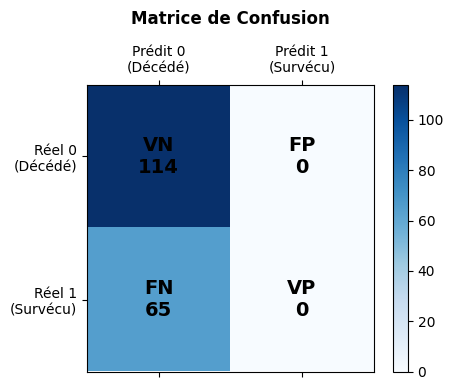

In [50]:
y_p = y_pred_test.flatten()
y_t = y_test_T.flatten()

VP = int(np.sum((y_p == 1) & (y_t == 1)))
VN = int(np.sum((y_p == 0) & (y_t == 0)))
FP = int(np.sum((y_p == 1) & (y_t == 0)))
FN = int(np.sum((y_p == 0) & (y_t == 1)))

print('=== Matrice de Confusion ===')
print(f'  VP = {VP}  |  FP = {FP}')
print(f'  FN = {FN}  |  VN = {VN}')


precision = VP / (VP + FP + 1e-8)
rappel    = VP / (VP + FN + 1e-8)
f1        = 2 * precision * rappel / (precision + rappel + 1e-8)

print(f'\nPrécision : {precision:.4f}')
print(f'Rappel    : {rappel:.4f}')
print(f'F1-score  : {f1:.4f}')

conf_matrix = np.array([[VN, FP], [FN, VP]])
fig, ax = plt.subplots(figsize=(5, 4))
cax = ax.matshow(conf_matrix, cmap='Blues')
plt.colorbar(cax)
labels = [['VN', 'FP'], ['FN', 'VP']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{labels[i][j]}\n{conf_matrix[i,j]}',
                ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_xticklabels(['', 'Prédit 0\n(Décédé)', 'Prédit 1\n(Survécu)'])
ax.set_yticklabels(['', 'Réel 0\n(Décédé)', 'Réel 1\n(Survécu)'])
ax.set_title('Matrice de Confusion', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Q21 — Courbe ROC et AUC

AUC manuel   : 0.5000
AUC sklearn  : 0.4514


/tmp/ipykernel_9631/2908773622.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_manuel = -np.trapz(tprs, fprs)


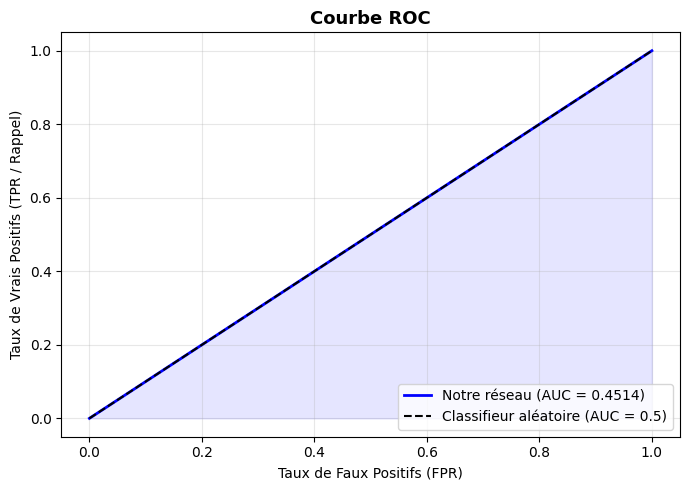

In [54]:
thresholds = np.linspace(0, 1, 100)
fprs, tprs = [], []

y_hat_flat = y_hat_test.flatten()
y_t_flat   = y_test_T.flatten()

for t in thresholds:
    y_pred_t = (y_hat_flat >= t).astype(int)
    VP_t = np.sum((y_pred_t == 1) & (y_t_flat == 1))
    FP_t = np.sum((y_pred_t == 1) & (y_t_flat == 0))
    FN_t = np.sum((y_pred_t == 0) & (y_t_flat == 1))
    VN_t = np.sum((y_pred_t == 0) & (y_t_flat == 0))
    tprs.append(VP_t / (VP_t + FN_t + 1e-8))
    fprs.append(FP_t / (FP_t + VN_t + 1e-8))

auc_manuel = -np.trapz(tprs, fprs)

auc_sklearn = roc_auc_score(y_t_flat, y_hat_flat)

print(f'AUC manuel   : {auc_manuel:.4f}')
print(f'AUC sklearn  : {auc_sklearn:.4f}')

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fprs, tprs, 'b-', linewidth=2, label=f'Notre réseau (AUC = {auc_sklearn:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Classifieur aléatoire (AUC = 0.5)')
ax.fill_between(fprs, tprs, alpha=0.1, color='blue')
ax.set_title('Courbe ROC', fontsize=13, fontweight='bold')
ax.set_xlabel('Taux de Faux Positifs (FPR)')
ax.set_ylabel('Taux de Vrais Positifs (TPR / Rappel)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Q22 — Comparaison avec le classifieur naïf

In [55]:
classe_majoritaire = int(np.round(y_train_T.mean()))
y_naif = np.full_like(y_t_flat, classe_majoritaire)

acc_naif = float(np.mean(y_naif == y_t_flat))
auc_naif = 0.5

print('=== Comparaison : Notre réseau vs Classifieur naïf ===')
print(f'  Classe majoritaire prédite : {classe_majoritaire} (décédé)')
print(f'  Accuracy naïf   : {acc_naif:.4f} ({acc_naif:.1%})')
print(f'  Accuracy réseau : {acc_test:.4f} ({acc_test:.1%})')
print(f'  AUC naïf        : {auc_naif:.4f}')
print(f'  AUC réseau      : {auc_sklearn:.4f}')
print(f'  Gain accuracy   : +{acc_test - acc_naif:.4f}')
print(f'  Gain AUC        : +{auc_sklearn - auc_naif:.4f}')

=== Comparaison : Notre réseau vs Classifieur naïf ===
  Classe majoritaire prédite : 0 (décédé)
  Accuracy naïf   : 0.6369 (63.7%)
  Accuracy réseau : 0.6369 (63.7%)
  AUC naïf        : 0.5000
  AUC réseau      : 0.4514
  Gain accuracy   : +0.0000
  Gain AUC        : +-0.0486


Q23 — Analyse de l'overfitting

In [56]:
ecart = abs(acc_train - acc_test)
print(f'Accuracy Train : {acc_train:.4f}')
print(f'Accuracy Test  : {acc_test:.4f}')
print(f'Écart          : {ecart:.4f} ({ecart:.1%})')

if ecart > 0.05:
    print('\n  Overfitting détecté (écart > 5%)')
    print('Stratégies pour réduire l\'overfitting :')
    print('  1. Régularisation L2 : pénalise les grands poids (W += λ·W)')
    print('  2. Dropout : désactive aléatoirement des neurones pendant le train')
    print('  3. Réduire la complexité : moins de neurones ou moins de couches')
    print('  4. Early stopping : arrêter quand la val loss commence à monter')
else:
    print('\n Pas d\'overfitting significatif (écart ≤ 5%)')


Accuracy Train : 0.6110
Accuracy Test  : 0.6369
Écart          : 0.0259 (2.6%)

 Pas d'overfitting significatif (écart ≤ 5%)


**Résumé Final — Tableau de Bord**

In [57]:
print('=' * 50)
print('       RÉSUMÉ DES PERFORMANCES')
print('=' * 50)
print(f'Architecture       : 6 → 8 → 8 → 4 → 1')
print(f'Activation         : Sigmoïde (toutes couches)')
print(f'Coût               : Binary Cross-Entropy')
print(f'Optimizer          : SGD batch (alpha=0.01)')
print(f'Epochs             : 1 000')
print('-' * 50)
print(f'Accuracy Train     : {acc_train:.4f} ({acc_train:.1%})')
print(f'Accuracy Test      : {acc_test:.4f} ({acc_test:.1%})')
print(f'AUC-ROC            : {auc_sklearn:.4f}')
print(f'Précision          : {precision:.4f}')
print(f'Rappel             : {rappel:.4f}')
print(f'F1-score           : {f1:.4f}')
print('-' * 50)
print(f'Baseline (naïf)    : {acc_naif:.4f} ({acc_naif:.1%})')
print(f'Gain vs baseline   : +{acc_test - acc_naif:.4f} ({(acc_test - acc_naif):.1%})')
print('=' * 50)

       RÉSUMÉ DES PERFORMANCES
Architecture       : 6 → 8 → 8 → 4 → 1
Activation         : Sigmoïde (toutes couches)
Coût               : Binary Cross-Entropy
Optimizer          : SGD batch (alpha=0.01)
Epochs             : 1 000
--------------------------------------------------
Accuracy Train     : 0.6110 (61.1%)
Accuracy Test      : 0.6369 (63.7%)
AUC-ROC            : 0.4514
Précision          : 0.0000
Rappel             : 0.0000
F1-score           : 0.0000
--------------------------------------------------
Baseline (naïf)    : 0.6369 (63.7%)
Gain vs baseline   : +0.0000 (0.0%)
